In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Data Quality Assessement

In [23]:
store=pd.read_csv(r"C:\Users\heman\Dropbox\PC\Documents\GitHub\Store_Sales\store.csv")
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [6]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [7]:
store.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


In [8]:
store.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [12]:
store.columns[store.isnull().any()]

Index(['CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2SinceWeek', 'Promo2SinceYear',
       'PromoInterval'],
      dtype='object')

In [13]:
#calculate the percentage of missing values for each column and patterns
for col in store.columns:
    missing_percentage = store[col].isnull().mean() * 100
    print(f"{col}: {missing_percentage:.2f}% missing values")

Store: 0.00% missing values
StoreType: 0.00% missing values
Assortment: 0.00% missing values
CompetitionDistance: 0.27% missing values
CompetitionOpenSinceMonth: 31.75% missing values
CompetitionOpenSinceYear: 31.75% missing values
Promo2: 0.00% missing values
Promo2SinceWeek: 48.79% missing values
Promo2SinceYear: 48.79% missing values
PromoInterval: 48.79% missing values


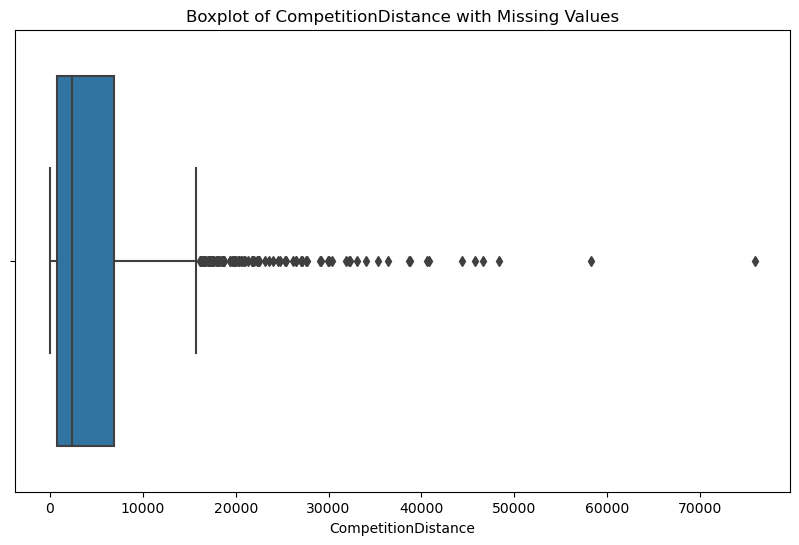

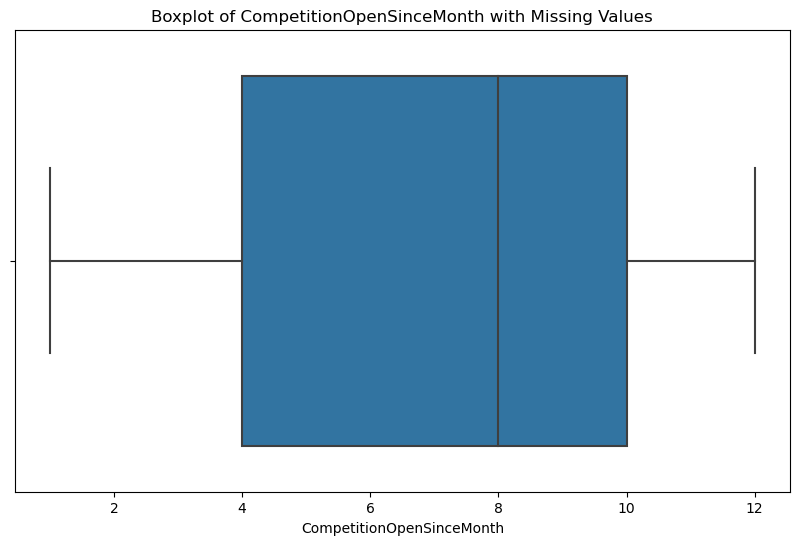

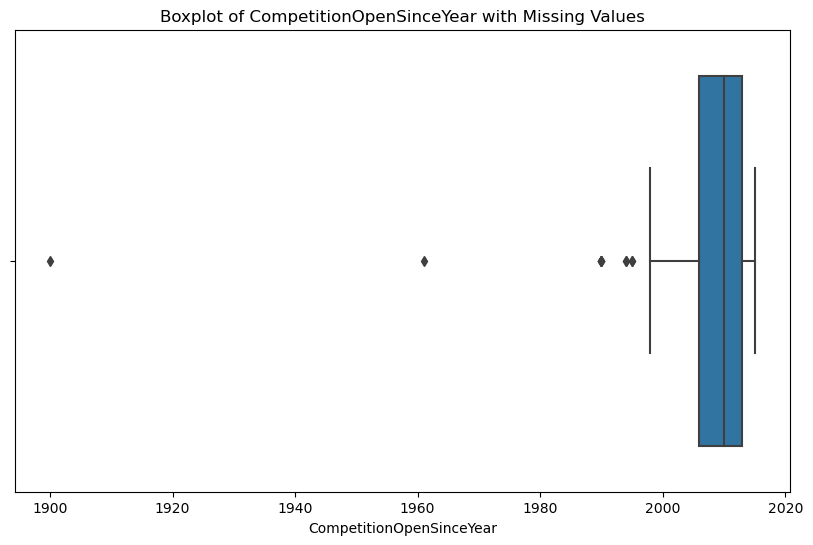

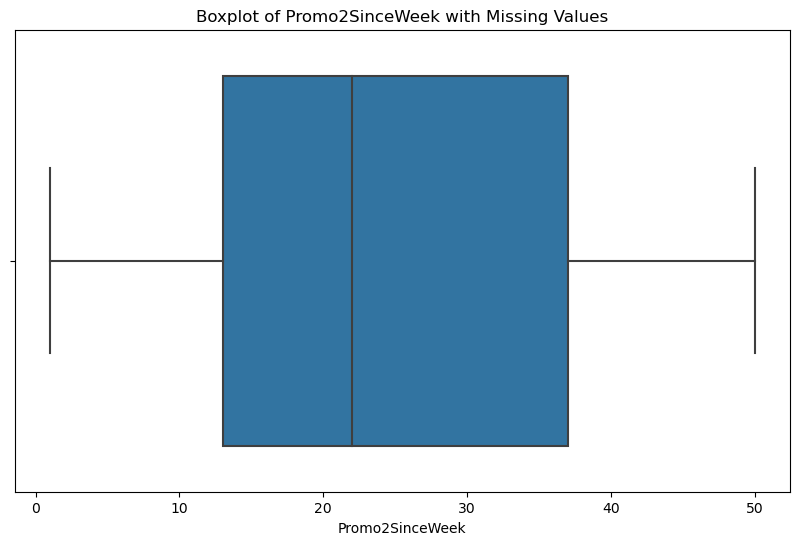

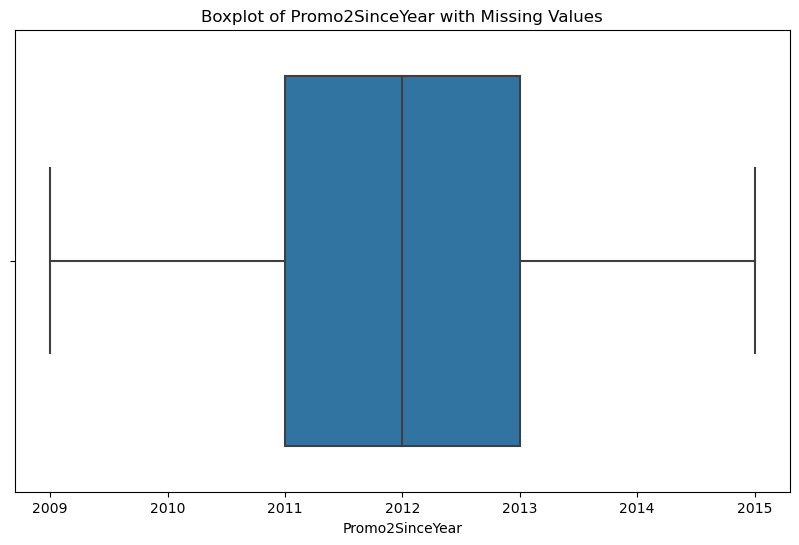

In [15]:
#identify if the numeric missing values are random or have a pattern
for col in store.columns:
    if store[col].isnull().any() and pd.api.types.is_numeric_dtype(store[col]):
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=store[col])
        plt.title(f"Boxplot of {col} with Missing Values")
        plt.show()

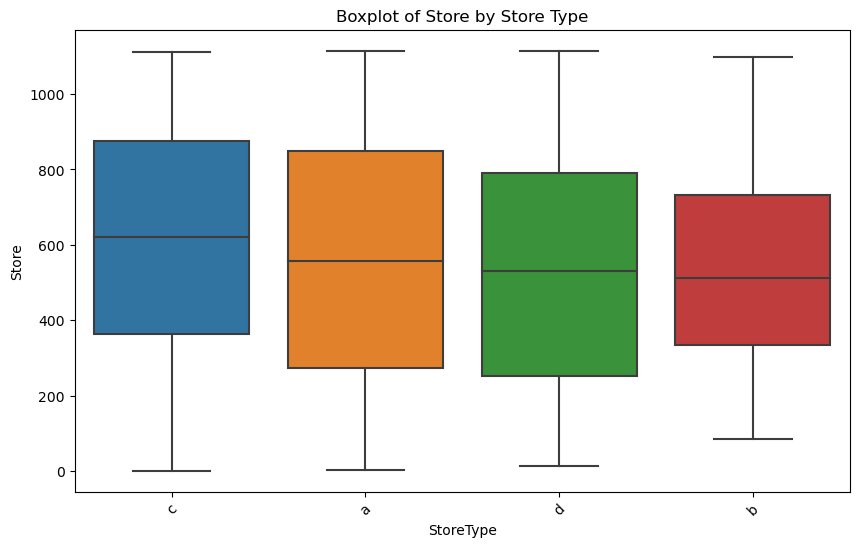

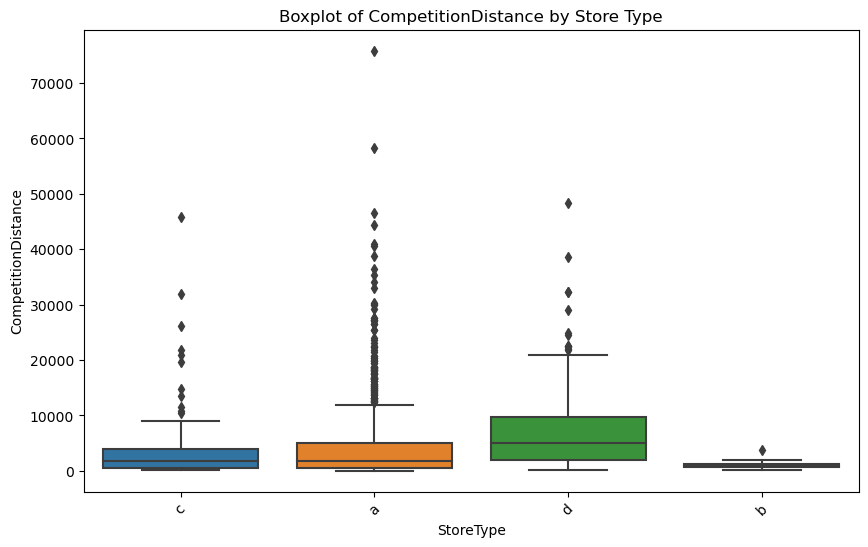

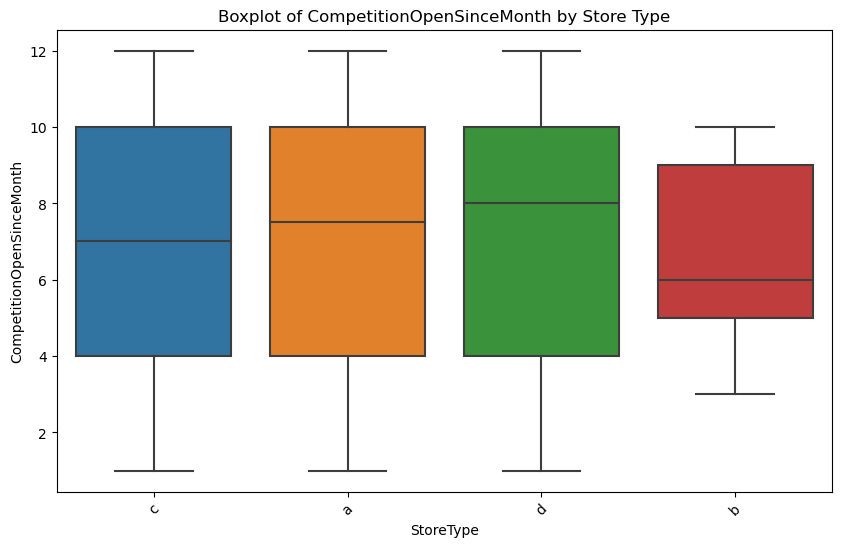

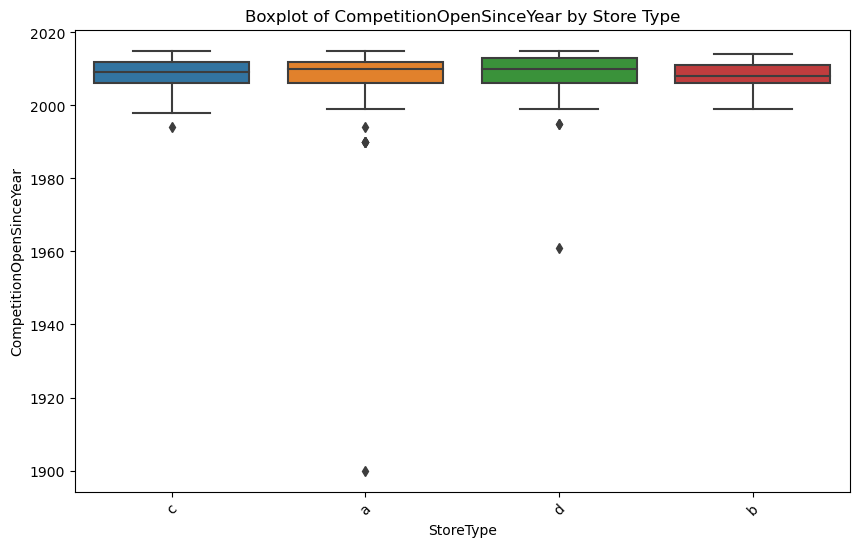

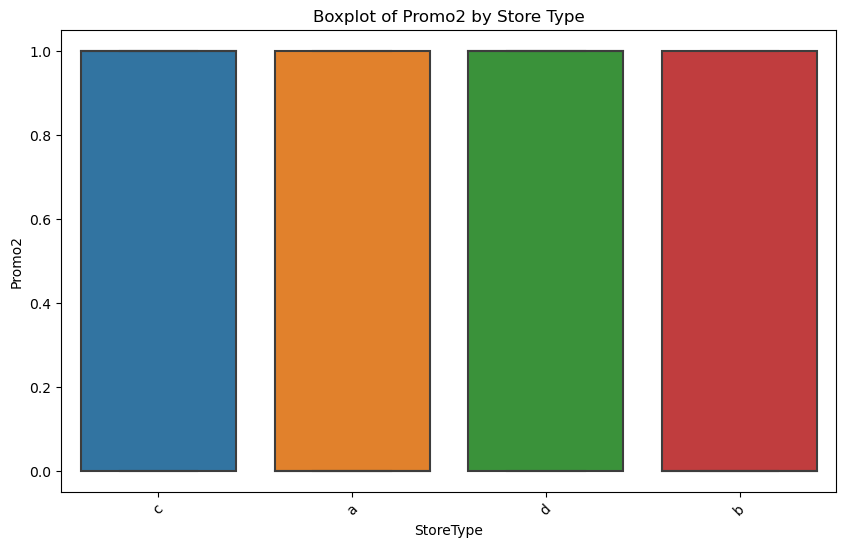

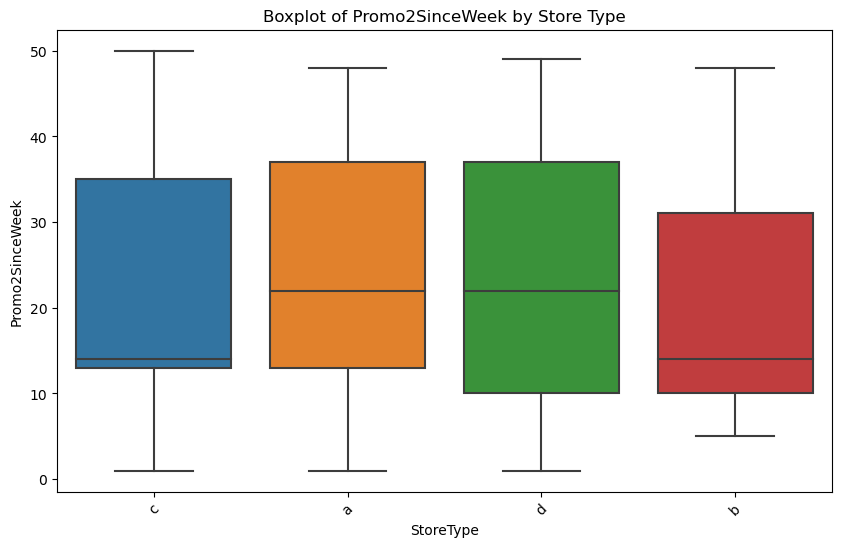

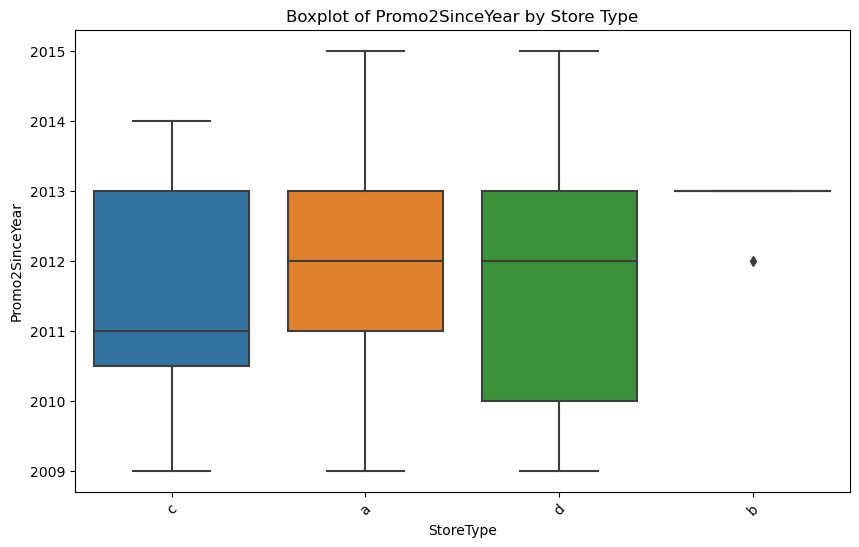

In [28]:
#creating box plot to visualize the store type and the numeric columns
for col in store.columns:
    if pd.api.types.is_numeric_dtype(store[col]):
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='StoreType', y=col, data=store)
        plt.title(f"Boxplot of {col} by Store Type")
        plt.xticks(rotation=45)
        plt.show()
    

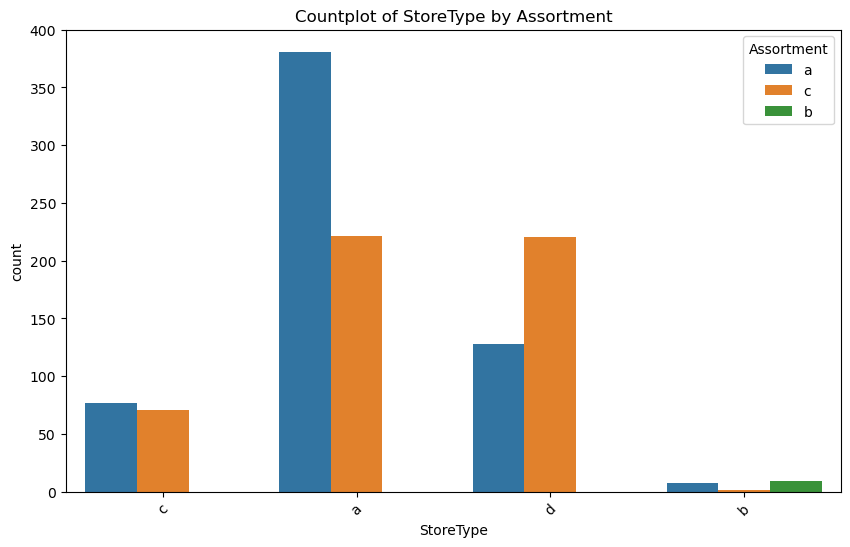

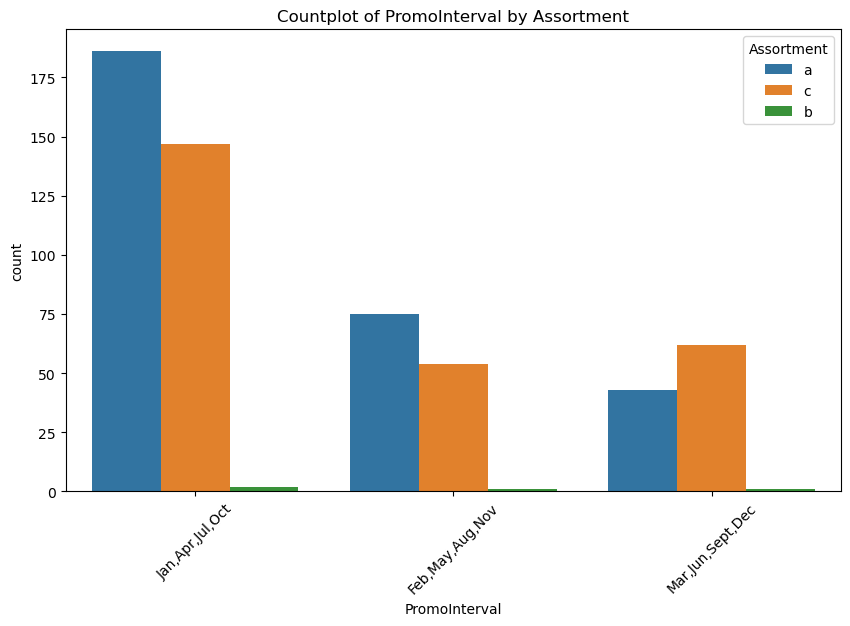

In [26]:
#Analyze the assortment column with relation to other categorical variables
for col in store.columns:
    if store[col].dtype == 'object' and col != 'Assortment':
        plt.figure(figsize=(10, 6))
        sns.countplot(x=store[col], hue=store['Assortment'])
        plt.title(f"Countplot of {col} by Assortment")
        plt.xticks(rotation=45)
        plt.show()

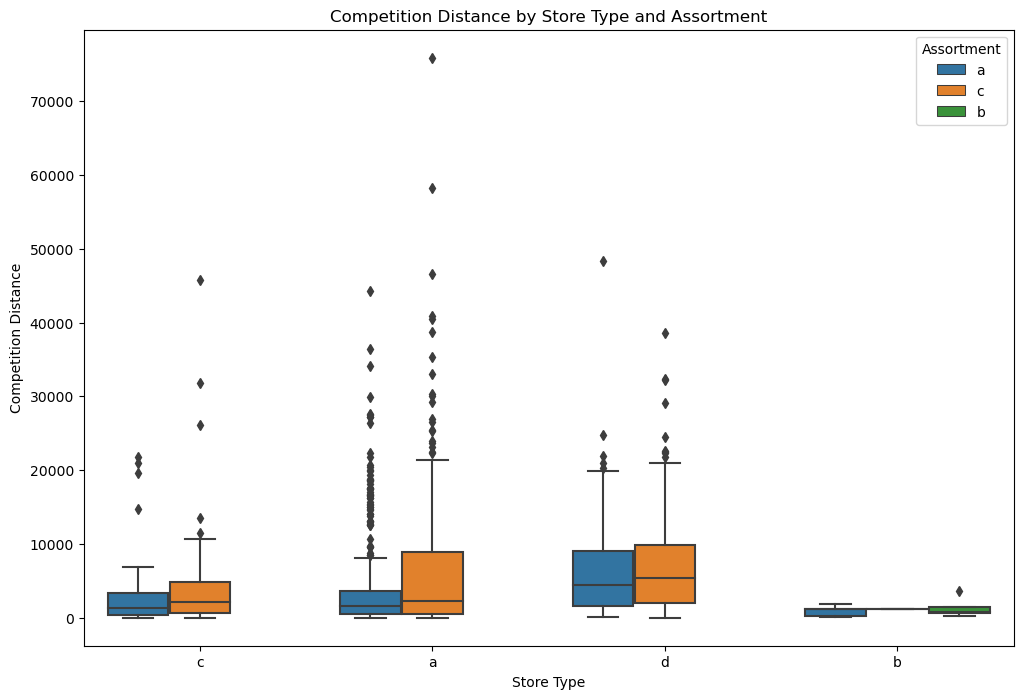

In [27]:
#creating a parallel box plot for store types and assortment with respect to competition distance
plt.figure(figsize=(12, 8))
sns.boxplot(x='StoreType', y='CompetitionDistance', hue='Assortment', data=store)
plt.title('Competition Distance by Store Type and Assortment')
plt.xlabel('Store Type')
plt.ylabel('Competition Distance')
plt.show()


In [31]:
#number of stores that do not have any competition information
no_competition = store[(store['CompetitionOpenSinceMonth'].isnull()) & (store['CompetitionOpenSinceYear'].isnull())]
print(f"Number of stores with no competition information: {len(no_competition)}")

#count the types of stores that do not have any competition information
competition_type_counts = no_competition['StoreType'].value_counts()
print("Count of each store type with no competition information:")
print(competition_type_counts)


Number of stores with no competition information: 354
Count of each store type with no competition information:
StoreType
a    176
d    129
c     41
b      8
Name: count, dtype: int64


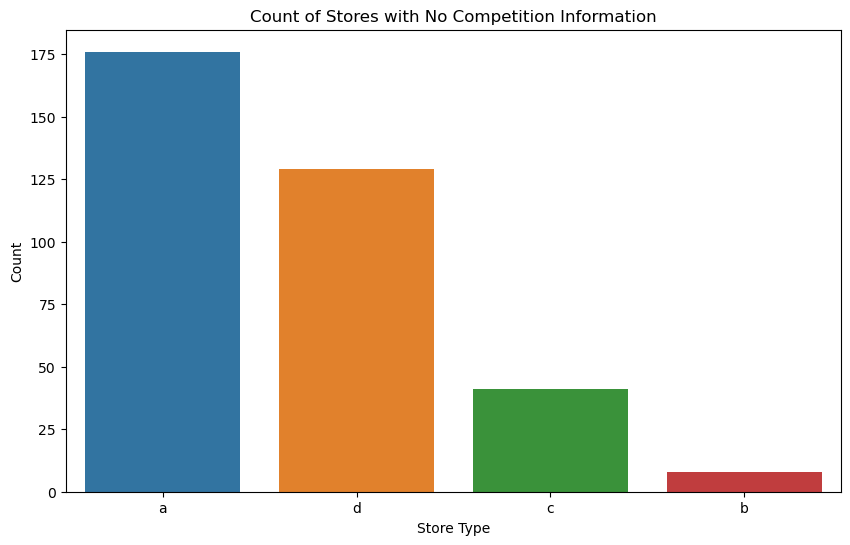

In [29]:
#Analyze the store types that do not have any competetionopensincemonth and competitionopensinceyear values
no_competition = store[(store['CompetitionOpenSinceMonth'].isnull()) & (store['CompetitionOpenSinceYear'].isnull())]
plt.figure(figsize=(10, 6))
sns.countplot(x='StoreType', data=no_competition)
plt.title('Count of Stores with No Competition Information')
plt.xlabel('Store Type')
plt.ylabel('Count')
plt.show()

In [ ]:
#wherever there is no competition is the promo2 present or not
no_competition_promo2 = no_competition['Promo2'].value_counts()
print("Count of each promo2 status for stores with no competition information:")
print(no_competition_promo2)

Count of each promo2 status for stores with no competition information:
Promo2
1    206
0    148
Name: count, dtype: int64


Despite not having competetions there are 206 stores that are giving promo coupons

Count of each store type with Promo2 active and no competition information:
StoreType
a    89
d    84
c    28
b     5
Name: count, dtype: int64


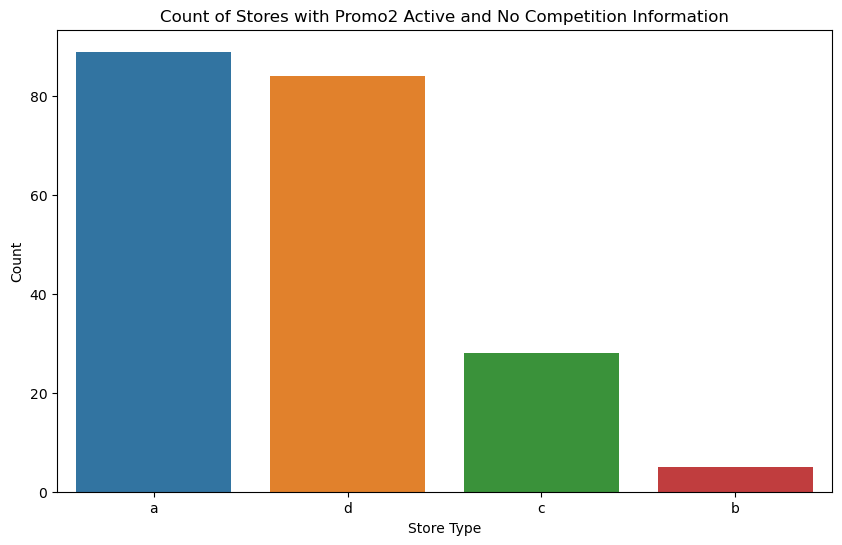

In [33]:
#what types of store are giving promo2 when there is not competition
no_competition_promo2_types = no_competition[no_competition['Promo2'] == 1]['StoreType'].value_counts()
print("Count of each store type with Promo2 active and no competition information:")
print(no_competition_promo2_types)

#visualize the stores that have promo2 active and no competition information
plt.figure(figsize=(10, 6))
sns.countplot(x='StoreType', data=no_competition[no_competition['Promo2'] == 1])
plt.title('Count of Stores with Promo2 Active and No Competition Information')
plt.xlabel('Store Type')
plt.ylabel('Count')
plt.show()

In [ ]:
#are there any records where promo is present but the promo2sinceweek, promo2sinceyear and promointerval are missing
promo_without_promo2_info = store[(store['Promo2'] == 1) & (store['Promo2SinceWeek'].isnull()) & (store['Promo2SinceYear'].isnull()) & (store['PromoInterval'].isnull())]
print(f"Number of records with Promo active but no Promo2 information: {len(promo_without_promo2_info)}")


Number of records with Promo active but no Promo2 information: 0


In [ ]:
#are there any records where promo is absent but the promo2sinceweek, promo2sinceyear and promointerval are present
promo2_with_missing_info = store[(store['Promo2'] == 0) & (store['Promo2SinceWeek'].notnull()) & (store['Promo2SinceYear'].notnull()) & (store['PromoInterval'].notnull())]
print(f"Number of records with Promo2 absent but missing information: {len(promo2_with_missing_info)}")

Number of records with Promo2 absent but missing information: 0


In [16]:
#check for duplicate records
duplicate_records = store.duplicated()
print(f"Number of duplicate records: {duplicate_records.sum()}")

Number of duplicate records: 0


In [17]:
#verify the data types are correct for each column
for col in store.columns:
    print(f"{col}: {store[col].dtype}")
    

Store: int64
StoreType: object
Assortment: object
CompetitionDistance: float64
CompetitionOpenSinceMonth: float64
CompetitionOpenSinceYear: float64
Promo2: int64
Promo2SinceWeek: float64
Promo2SinceYear: float64
PromoInterval: object


#Missing Value Analysis
#Analyze columns with missing values
for col in store.columns:
    if store[col].isnull().any():
        plt.figure(figsize=(10, 6))
        sns.countplot(x=store[col])
        plt.title(f"Countplot of {col} with Missing Values")
        plt.xticks(rotation=45)
        plt.show()

### Distribution of the columns

In [20]:
#Explore the dataset
store.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


### Imputation Strategy